# interrupting and continuing of a simulation with a source

In this example the simulation uses a `sourceInterface` and allows for the production of secondaries.

The source emmits a limited number of photons ($n = 100$) with an energy $E = 100 \, \mathrm{TeV}$ at a distance of $D = 50 \, \mathrm{Mpc}$. The photons are propagated in 1D to the observer, taking interactions with the CMB and EBL into account. 

The interrupted simulation contains three different parts: (1) the candidates arriving at the observer before the simulation is interrupted, (2) the candidates which are in the simulation at the point of interruption and (3) the particles which have not been started before the interruption. In the case of secondaries the number of particles which are contained in the simulation is much larger than the number of cores. 

In the end, the SED of the arriving photons is compared. Small differences between the full and the interrupted simulation are expected due to the Monte-Carlo nature of the interactions. 

In [1]:
from crpropa import * 
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import os 

In [2]:
def read_crp(file): 
    with open(file, "r") as f: 
        names = f.readline().strip("\n").split("\t")[1:]
    
    return pd.read_csv(file, delimiter="\t", comment ="#", names = names)

## full simulation

In [3]:
n_sim = int(100)

def get_sim(file):
    sim = ModuleList() 
    sim.add(SimplePropagation())

    # add EM interactions 
    photon_fields = [CMB(), IRB_Gilmore12()]
    for field in photon_fields:
        sim.add(EMInverseComptonScattering(field, True)) # allow photons
        sim.add(EMPairProduction(field, True)) # allow electrons 
        sim.add(EMDoublePairProduction(field, True))
        sim.add(EMTripletPairProduction(field, True))

    sim.add(MinimumEnergy(10 * GeV))

    sub_dir = "cascade/"
    os.makedirs(sub_dir, exist_ok=True)
    out = TextOutput(f"{sub_dir}/{file}")
    out.setEnergyScale(TeV)
    obs = Observer() 
    obs.add(Observer1D())
    obs.add(ObserverInactiveVeto())
    obs.onDetection(out)
    sim.add(obs) 

    source = Source() 
    source.add(SourceParticleType(22))
    source.add(SourcePosition(Vector3d(50 * Mpc, 0, 0)))
    source.add(SourceEnergy(100 * TeV))

    sim.setShowProgress(True)
    return source, sim, out

source, sim, out = get_sim("full.txt")
sim.run(source, n_sim)
out.close()

crpropa::ModuleList: Number of Threads: 32
Run ModuleList


2026-07-22 02:45:17 [WARNING] EMPaiProduction: Sampled s value is the lowest tabulated value, which is not physical. The index j will be set to 1 to avoid division by zero.
2026-07-22 02:45:17 [WARNING] EMPaiProduction: Sampled s value is the lowest tabulated value, which is not physical. The index j will be set to 1 to avoid division by zero.
2026-07-22 02:45:17 [WARNING] EMPaiProduction: Sampled s value is the lowest tabulated value, which is not physical. The index j will be set to 1 to avoid division by zero.
2026-07-22 02:45:17 [WARNING] EMPaiProduction: Sampled s value is the lowest tabulated value, which is not physical. The index j will be set to 1 to avoid division by zero.
2026-07-22 02:45:17 [WARNING] EMPaiProduction: Sampled s value is the lowest tabulated value, which is not physical. The index j will be set to 1 to avoid division by zero.
2026-07-22 02:45:17 [WARNING] EMPaiProduction: Sampled s value is the lowest tabulated value, which is not physical. The index j will b

2026-07-22 02:45:19 [WARNING] EMPaiProduction: Sampled s value is the lowest tabulated value, which is not physical. The index j will be set to 1 to avoid division by zero.


2026-07-22 02:45:20 [WARNING] EMPaiProduction: Sampled s value is the lowest tabulated value, which is not physical. The index j will be set to 1 to avoid division by zero.


2026-07-22 02:45:20 [WARNING] EMPaiProduction: Sampled s value is the lowest tabulated value, which is not physical. The index j will be set to 1 to avoid division by zero.


...

2026-07-22 02:45:28 [WARNING] EMPaiProduction: Sampled s value is the lowest tabulated value, which is not physical. The index j will be set to 1 to avoid division by zero.
2026-07-22 02:45:28 [WARNING] EMPaiProduction: Sampled s value is the lowest tabulated value, which is not physical. The index j will be set to 1 to avoid division by zero.


2026-07-22 02:45:29 [WARNING] EMPaiProduction: Sampled s value is the lowest tabulated value, which is not physical. The index j will be set to 1 to avoid division by zero.


2026-07-22 02:45:30 [WARNING] EMPaiProduction: Sampled s value is the lowest tabulated value, which is not physical. The index j will be set to 1 to avoid division by zero.


2026-07-22 02:45:31 [WARNING] EMPaiProduction: Sampled s value is the lowest tabulated value, which is not physical. The index j will be set to 1 to avoid division by zero.


  Started Wed Jul 22 02:45:17 2026 : [ Finished ] 100%    Needed: 00:00:18  - Finished at Wed Jul 22 02:45:35 2026


In [4]:
# load data 
df_full = read_crp("cascade/full.txt")

## interrupted simulation

In [5]:
source, sim, out = get_sim("interrupt_1.txt")

interrupt_out = TextOutput(f"cascade/on_interrupt.txt")
sim.setInterruptAction(interrupt_out)

sim.run(source, n_sim)

crpropa::ModuleList: Number of Threads: 32
Run ModuleList


2026-07-22 02:45:35 [WARNING2026-07-22 02:45:35 [WARNING] EMPaiProduction: Sampled s value is the lowest tabulated value, which is not physical. The index j will be set to 1 to avoid division by zero.
2026-07-22 02:45:35 [WARNING] 2026-07-22 02:45:35 EMPaiProduction: Sampled s value is the lowest tabulated value, which is not physical.] [WARNING] EMPaiProduction: Sampled s value is the lowest tabulated value, which is not physical. The index j will be set to 1 to avoid division by zero.
 The index j will be set to 1 to avoid division by zero.
EMPaiProduction: Sampled s value is the lowest tabulated value, which is not physical. The index j will be set to 1 to avoid division by zero.
2026-07-22 02:45:35 2026-07-22 02:45:35 [WARNING] EMPaiProduction: Sampled s value is the lowest tabulated value, which is not physical. The index j will be set to 1 to avoid division by zero.
[WARNING] EMPaiProduction: Sampled s value is the lowest tabulated value, which is not physical. The index j will b

2026-07-22 02:45:37 [WARNING] EMPaiProduction: Sampled s value is the lowest tabulated value, which is not physical. The index j will be set to 1 to avoid division by zero.
2026-07-22 02:45:38 [WARNING] EMPaiProduction: Sampled s value is the lowest tabulated value, which is not physical. The index j will be set to 1 to avoid division by zero.


2026-07-22 02:45:38 [WARNING] EMPaiProduction: Sampled s value is the lowest tabulated value, which is not physical. The index j will be set to 1 to avoid division by zero.


2026-07-22 02:45:40 [WARNING] EMPaiProduction: Sampled s value is the lowest tabulated value, which is not physical. The index j will be set to 1 to avoid division by zero.
2026-07-22 02:45:40 [WARNING] EMPaiProduction: Sampled s value is the lowest tabulated value, which is not physical. The index j will be set to 1 to avoid division by zero.


...

2026-07-22 02:45:41 [WARNING] ModuleList::dumpCandidate is called with a non active candidate. This should not happen for the interrupt action. Please check candidate with serial number 9778778

2026-07-22 02:45:41 [WARNING] ModuleList::dumpCandidate is called with a non active candidate. This should not happen for the interrupt action. Please check candidate with serial number 9778799

2026-07-22 02:45:41 [WARNING] ModuleList::dumpCandidate is called with a non active candidate. This should not happen for the interrupt action. Please check candidate with serial number 10513166

2026-07-22 02:45:41 [WARNING] ModuleList::dumpCandidate is called with a non active candidate. This should not happen for the interrupt action. Please check candidate with serial number 10513217

2026-07-22 02:45:42 [WARNING] ModuleList::dumpCandidate is called with a non active candidate. This should not happen for the interrupt action. Please check candidate with serial number 10599773

2026-07-22 02:45:42 [W

2026-07-22 02:45:42 [WARNING] ModuleList::dumpCandidate is called with a non active candidate. This should not happen for the interrupt action. Please check candidate with serial number 10806750

2026-07-22 02:45:42 [WARNING] ModuleList::dumpCandidate is called with a non active candidate. This should not happen for the interrupt action. Please check candidate with serial number 10599732

2026-07-22 02:45:42 [WARNING] ModuleList::dumpCandidate is called with a non active candidate. This should not happen for the interrupt action. Please check candidate with serial number 9146095

2026-07-22 02:45:42 [WARNING] ModuleList::dumpCandidate is called with a non active candidate. This should not happen for the interrupt action. Please check candidate with serial number 9146134

2026-07-22 02:45:42 [WARNING] ModuleList::dumpCandidate is called with a non active candidate. This should not happen for the interrupt action. Please check candidate with serial number 9146176

2026-07-22 02:45:42 [WA

2026-07-22 02:45:42 [WARNING] ModuleList::dumpCandidate is called with a non active candidate. This should not happen for the interrupt action. Please check candidate with serial number 10444612

2026-07-22 02:45:42 [WARNING] ModuleList::dumpCandidate is called with a non active candidate. This should not happen for the interrupt action. Please check candidate with serial number 11110135

2026-07-22 02:45:42 [WARNING] ModuleList::dumpCandidate is called with a non active candidate. This should not happen for the interrupt action. Please check candidate with serial number 11730664

2026-07-22 02:45:42 [WARNING] ModuleList::dumpCandidate is called with a non active candidate. This should not happen for the interrupt action. Please check candidate with serial number 11730689

2026-07-22 02:45:42 [WARNING] ModuleList::dumpCandidate is called with a non active candidate. This should not happen for the interrupt action. Please check candidate with serial number 11730715

2026-07-22 02:45:42 

############################################################################
# Interrupted CRPropa simulation 
# Number of not started candidates from source: 47
############################################################################


KeyboardInterrupt: 

In [6]:
# close datafile to avoid data loss
out.close()

In [7]:
df_1 = read_crp(f"cascade/interrupt_1.txt") # at state of interruption

In [8]:
n_missing = 69 # taken from output -> will be different on each try

source, sim, out = get_sim("interrupt_2.txt")
sim.run(source, n_missing) # use modulelist and source as previously defined
out.close()

crpropa::ModuleList: Number of Threads: 32
Run ModuleList


2026-07-22 02:45:49 [WARNING] EMPaiProduction: Sampled s value is the lowest tabulated value, which is not physical. The index j will be set to 1 to avoid division by zero.
2026-07-22 02:45:49 [WARNING] EMPaiProduction: Sampled s value is the lowest tabulated value, which is not physical. The index j will be set to 1 to avoid division by zero.
2026-07-22 02:45:49 [WARNING] EMPaiProduction: Sampled s value is the lowest tabulated value, which is not physical. The index j will be set to 1 to avoid division by zero.
2026-07-22 02:45:49 [WARNING] EMPaiProduction: Sampled s value is the lowest tabulated value, which is not physical. The index j will be set to 1 to avoid division by zero.


2026-07-22 02:45:51 [WARNING] EMPaiProduction: Sampled s value is the lowest tabulated value, which is not physical. The index j will be set to 1 to avoid division by zero.


2026-07-22 02:45:53 [WARNING] EMPaiProduction: Sampled s value is the lowest tabulated value, which is not physical. The index j will be set to 1 to avoid division by zero.
2026-07-22 02:45:53 [WARNING] EMPaiProduction: Sampled s value is the lowest tabulated value, which is not physical. The index j will be set to 1 to avoid division by zero.


2026-07-22 02:45:53 [WARNING] EMPaiProduction: Sampled s value is the lowest tabulated value, which is not physical. The index j will be set to 1 to avoid division by zero.


2026-07-22 02:45:54 [WARNING] EMPaiProduction: Sampled s value is the lowest tabulated value, which is not physical. The index j will be set to 1 to avoid division by zero.


2026-07-22 02:45:55 [WARNING] EMPaiProduction: Sampled s value is the lowest tabulated value, which is not physical. The index j will be set to 1 to avoid division by zero.


2026-07-22 02:45:56 [WARNING] EMPaiProduction: Sampled s value is the lowest tabulated value, which is not physical. The index j will be set to 1 to avoid division by zero.
2026-07-22 02:45:56 [WARNING] EMPaiProduction: Sampled s value is the lowest tabulated value, which is not physical. The index j will be set to 1 to avoid division by zero.


  Started Wed Jul 22 02:45:49 2026 : [ Finished ] 100%    Needed: 00:00:11  - Finished at Wed Jul 22 02:46:00 2026


In [9]:
df_2 = read_crp(f"cascade/interrupt_2.txt")

In [10]:
# close outputfile before reading 
interrupt_out.close()

pc = ParticleCollector()
pc.load("cascade/on_interrupt.txt")

print("number of loaded particles:", pc.size())

# run simulation with missing particles
source, sim, out = get_sim("interrupt_3.txt")
sim.run(pc.getContainer())
out.close()

number of loaded particles: 1066787
crpropa::ModuleList: Number of Threads: 32
Run ModuleList


2026-07-22 02:46:07 [WARNING] EMPaiProduction: Sampled s value is the lowest tabulated value, which is not physical. The index j will be set to 1 to avoid division by zero.


  Started Wed Jul 22 02:46:06 2026 : [ Finished ] 100%    Needed: 00:00:05  - Finished at Wed Jul 22 02:46:11 2026


In [11]:
try:
    df_3 = read_crp("cascade/interrupt_3.txt")
except: 
    # it can happen that all particles from the interruption time are cascaded to lower energies than the minimum energy
    # in this case the dataset will be empty
    print("no data from interrupt_3.txt")
    df_3 = pd.DataFrame({"E":[], "ID":[]})

## show spectrum at earth

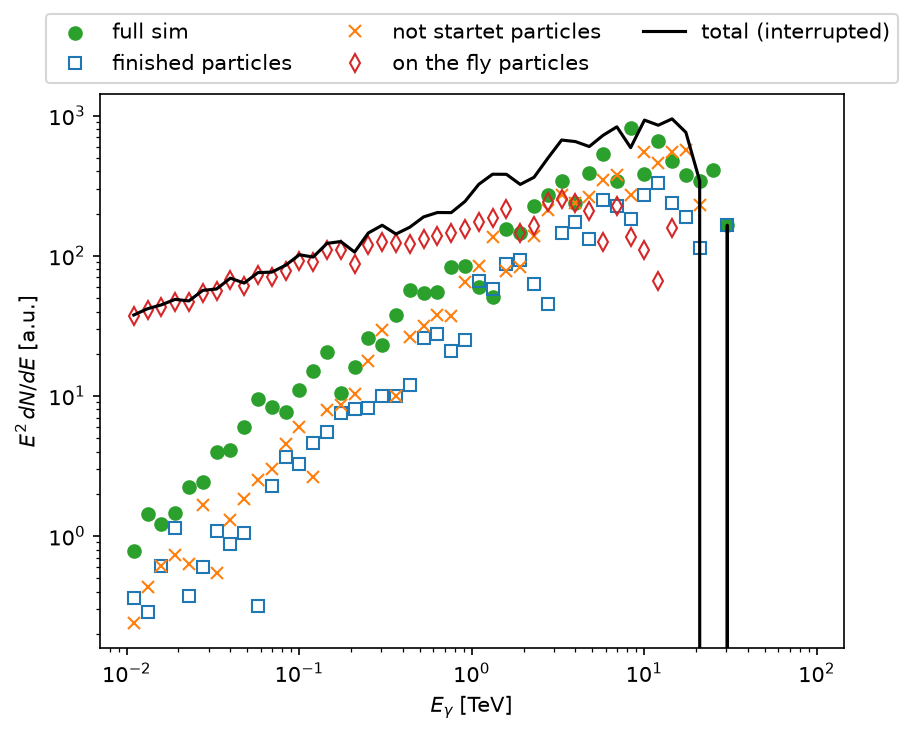

In [12]:
e_bins = np.logspace(-2, 2, 51)
dE = np.diff(e_bins)
e_mid = 0.5 * (e_bins[1:] + e_bins[:-1])

get_dnde = lambda df: np.histogram(df[df.ID == 22].E, bins = e_bins)[0]/dE 

dNdE_full = get_dnde(df_full)
dNdE_1 = get_dnde(df_1)
dNdE_2 = get_dnde(df_2)
dNdE_3 = get_dnde(df_3) 

plt.figure(dpi = 150)
plt.scatter(e_mid, e_mid**2 * dNdE_full, label = "full sim", color = "tab:green") 
plt.plot(e_mid, e_mid**2 * dNdE_1, label = "finished particles", marker ="s", ls = "", fillstyle="none")
plt.plot(e_mid, e_mid**2 * dNdE_2, label = "not startet particles", marker ="x", ls = "", )
plt.plot(e_mid, e_mid**2 * dNdE_3, label = "on the fly particles", fillstyle="none", ls = "",marker ="d", color = "tab:red")

plt.plot(e_mid, e_mid**2 * (dNdE_1 + dNdE_2 + dNdE_3), label ="total (interrupted)", color ="k")


plt.loglog() 
plt.xlabel(r"$E_\gamma$ [TeV]")
plt.ylabel(r"$E^2 \, dN/dE$ [a.u.]")
plt.legend(loc = "lower center", ncol = 3, bbox_to_anchor=(0.5, 1.))
plt.show()